# Практическое занятие 4

## Задача работы:
 Провести обработку данных о транзакциях кафе, включая оценку качества информации, ее очистку и преобразование, с целью вычисления ключевых показателей эффективности бизнеса.


## 1. Импортируем необходимые библиотеки.

In [ ]:

# Импорт необходимых модулей для анализа
import pandas as pd  # обработка структурированных данных
import numpy as np   # вычисления и работа с массивами

# Импорт инструментов визуализации
import matplotlib.pyplot as plt  # базовые графики
import seaborn as sns            # улучшенная визуализация


# 2. Предварительный анализ данных
# Загружаем данные из файла cafe.csv для первичного ознакомления со структурой и содержанием
df = pd.read_csv('cafe.csv')

# Используем методы .head() и .info() для получения общей информации о данных:
# - количество строк и столбцов в наборе данных
# - типы данных каждого столбца  
# - наличие явных пропусков в данных
# - основные статистические показатели для числовых полей

print("Первые записи датасета для визуального ознакомления:")
display(df.head())

print("\nДетальная информация о структуре данных:")
df.info()

# Анализ пропусков - df.isnull().sum() - подсчитываем количество пропущенных значений
# (NaN/None) в каждом столбце для оценки полноты данных
print("\nАнализ пропущенных значений по столбцам:")
missing_count = df.isnull().sum()
print(missing_count)

# Проверка уникальных значений - выявляем аномалии в данных
# Любые значения, не входящие в ожидаемый список (например, ERROR, UNKNOWN, пустые строки),
# будут считаться аномалиями и требуют дополнительной обработки

In [ ]:
# Загрузка данных о транзакциях кафе
df = pd.read_csv('cafe (4).csv')  # правильное имя файла
print(f"Объем данных: {df.shape}")
print(f"Число транзакционных записей: {len(df)}")

print("\n--- Структурная информация ---")
print(df.info())
print("\nВыборка первых 5 записей:")
display(df.head())

print("\n--- Аудит пропущенных значений ---")
missing_data = df.isnull().sum()
for column, missing_count in missing_data.items():
    if missing_count > 0:
        percentage_missing = (missing_count / len(df)) * 100
        print(f"Столбец '{column}': {missing_count} пропусков ({percentage_missing:.1f}%)")
    else:
        print(f"Столбец '{column}': пропуски отсутствуют")

print("\n--- Детектирование аномальных записей ---")
for column in df.columns:
    if column != 'Transaction ID':
        # Подсчет различных типов проблемных значений
        errors_detected = (df[column] == 'ERROR').sum()
        unknown_detected = (df[column] == 'UNKNOWN').sum()
        empty_strings = (df[column] == '').sum()
        total_anomalies = errors_detected + unknown_detected + empty_strings

        if total_anomalies > 0:
            print(f"Столбец '{column}': {total_anomalies} аномальных записей")
        else:
            print(f"Столбец '{column}': аномалии не обнаружены")

print("\n--- Анализ категориальных переменных ---")
print(f"Ассортимент товаров: {df['Item'].nunique()} наименований")
print(f"Используемые методы оплаты: {list(df['Payment Method'].unique())}")
print(f"География точек продаж: {list(df['Location'].unique())}")

print("\n--- Статистика числовых показателей ---")
print("Основные статистические характеристики:")
print(df.describe())

Объем данных: (10000, 8)
Число транзакционных записей: 10000

--- Структурная информация ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB
None

Выборка первых 5 записей:


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11



--- Аудит пропущенных значений ---
Столбец 'Transaction ID': пропуски отсутствуют
Столбец 'Item': 333 пропусков (3.3%)
Столбец 'Quantity': 138 пропусков (1.4%)
Столбец 'Price Per Unit': 179 пропусков (1.8%)
Столбец 'Total Spent': 173 пропусков (1.7%)
Столбец 'Payment Method': 2579 пропусков (25.8%)
Столбец 'Location': 3265 пропусков (32.6%)
Столбец 'Transaction Date': 159 пропусков (1.6%)

--- Детектирование аномальных записей ---
Столбец 'Item': 636 аномальных записей
Столбец 'Quantity': 341 аномальных записей
Столбец 'Price Per Unit': 354 аномальных записей
Столбец 'Total Spent': 329 аномальных записей
Столбец 'Payment Method': 599 аномальных записей
Столбец 'Location': 696 аномальных записей
Столбец 'Transaction Date': 301 аномальных записей

--- Анализ категориальных переменных ---
Ассортимент товаров: 10 наименований
Используемые методы оплаты: ['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR', nan]
География точек продаж: ['Takeaway', 'In-store', 'UNKNOWN', nan, 'ERRO

## 3. Обнаружение и анализ аномалий

**Расчет статистических показателей:**
Определение минимальных и максимальных значений, медианы, среднего арифметического и количества пропущенных данных. Это формирует точное количественное представление о качестве данных в каждом числовом столбце.

Создается рабочая копия DataFrame (df_clean) с добавлением новых столбцов, содержащих числовые представления Quantity, Price Per Unit и Total Spent.

Формируется маска несоответствий (discrepancy_mask), которая идентифицирует строки, где исходное значение Total Spent не совпадает с вычисленным значением Calculated_Total. Это позволяет выявить транзакции с арифметическими ошибками.

**Визуальная диагностика данных:**

График проблемных значений: отображает количество записей ERROR, UNKNOWN, пустых строк и значений NaN в ключевых столбцах. Позволяет визуально оценить наиболее проблемные атрибуты данных.

Топ товаров: показывает 8 наиболее популярных позиций меню, что помогает анализировать структуру продаж.

Методы оплаты: визуализирует распределение различных способов оплаты.

Локации: демонстрирует распределение заказов между точками продаж (In-store и Takeaway).

Распределение сумм чеков: отображает частоту встречаемости различных сумм транзакций, помогая выявить аномально высокие или низкие значения.

Распределение количества товаров: показывает типичное число единиц товара в одной транзакции, характеризующее средний размер заказа.

--- Анализ числовых показателей ---

Quantity:
  Минимальное значение: 1.0
  Максимальное значение: 5.0
  Медиана: 3.00
  Среднее арифметическое: 3.03
  Количество пропусков: 479

Price Per Unit:
  Минимальное значение: 1.0
  Максимальное значение: 5.0
  Медиана: 3.00
  Среднее арифметическое: 2.95
  Количество пропусков: 533

Total Spent:
  Минимальное значение: 1.0
  Максимальное значение: 25.0
  Медиана: 8.00
  Среднее арифметическое: 8.92
  Количество пропусков: 502

--- Верификация корректности расчетов ---
Обнаружено несоответствий в расчетах: 0


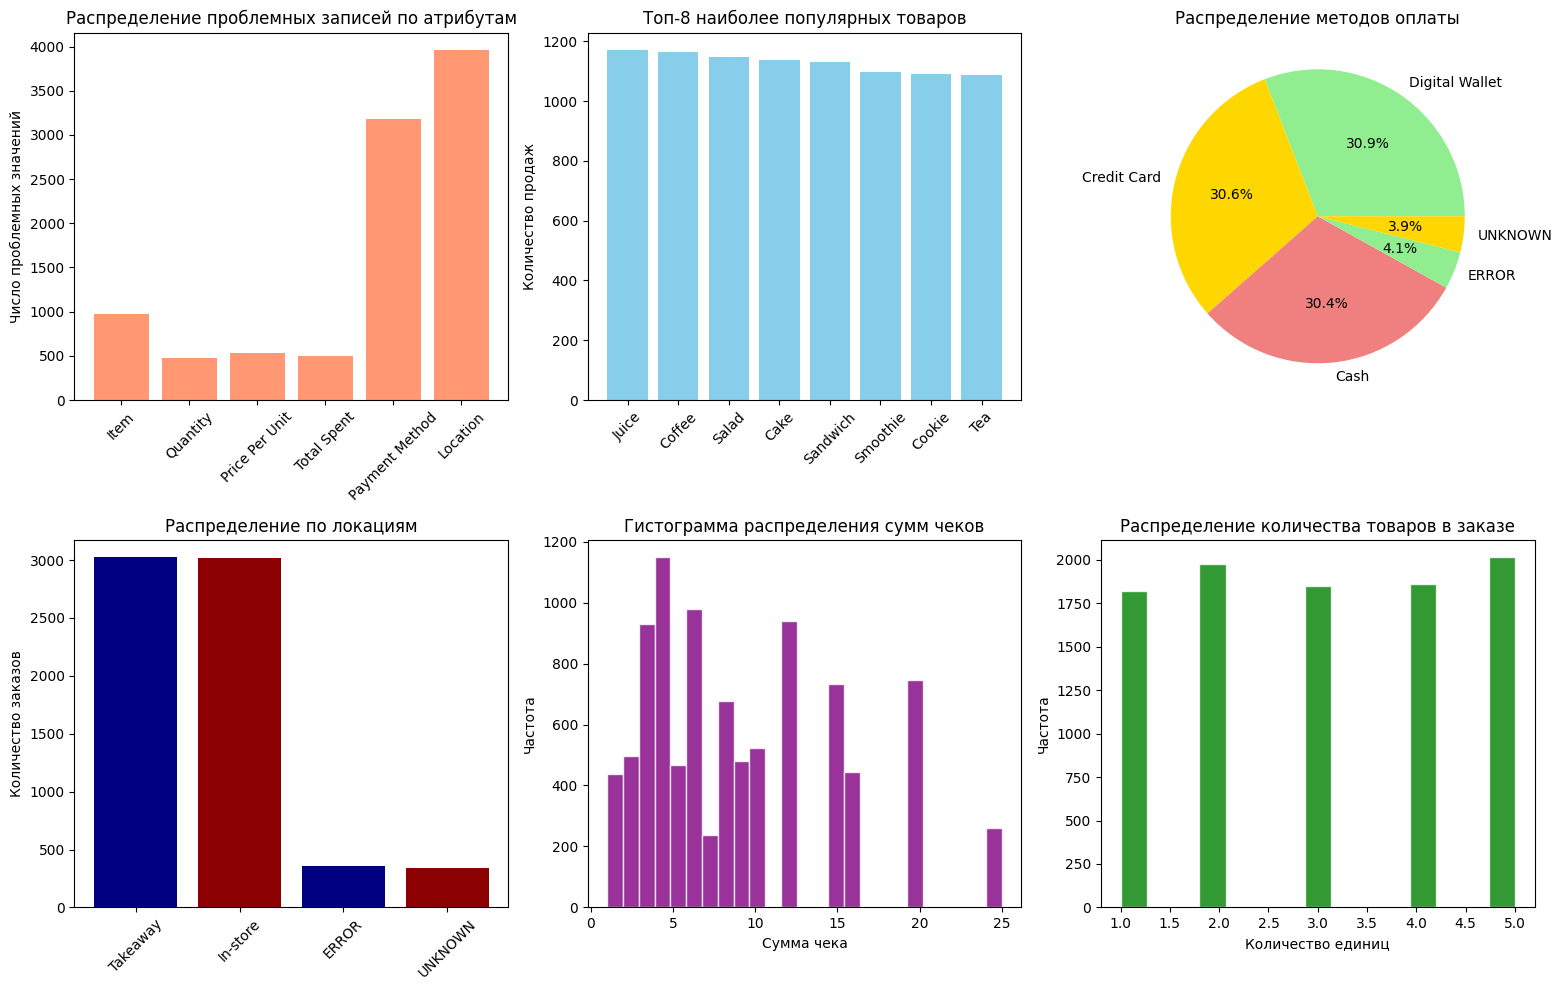


--- Ключевые выводы ---
1. Основные проблемы данных: значения ERROR, UNKNOWN, пропуски в критических атрибутах
2. Выявлены арифметические несоответствия в расчетах итоговых сумм
3. Требуется проведение процедур очистки и восстановления данных


In [ ]:
print("--- Анализ числовых показателей ---")
numeric_columns = ['Quantity', 'Price Per Unit', 'Total Spent']
for column in numeric_columns:
    numeric_series = pd.to_numeric(df[column], errors='coerce')
    print(f"\n{column}:")
    print(f"  Минимальное значение: {numeric_series.min()}")
    print(f"  Максимальное значение: {numeric_series.max()}")
    print(f"  Медиана: {numeric_series.median():.2f}")
    print(f"  Среднее арифметическое: {numeric_series.mean():.2f}")
    print(f"  Количество пропусков: {numeric_series.isna().sum()}")

print("\n--- Верификация корректности расчетов ---")
df_clean = df.copy()
df_clean['Quantity_numeric'] = pd.to_numeric(df_clean['Quantity'], errors='coerce')
df_clean['Price_numeric'] = pd.to_numeric(df_clean['Price Per Unit'], errors='coerce')
df_clean['Total_numeric'] = pd.to_numeric(df_clean['Total Spent'], errors='coerce')
df_clean['Calculated_Total'] = df_clean['Quantity_numeric'] * df_clean['Price_numeric']

calculation_discrepancies = (df_clean['Total_numeric'] != df_clean['Calculated_Total']) & \
                          (df_clean['Quantity_numeric'].notna()) & \
                          (df_clean['Price_numeric'].notna()) & \
                          (df_clean['Total_numeric'].notna())
discrepancy_count = calculation_discrepancies.sum()
print(f"Обнаружено несоответствий в расчетах: {discrepancy_count}")

plt.figure(figsize=(16, 10))

# График проблемных значений
problematic_data = []
analyzed_columns = ['Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location']
for column in analyzed_columns:
    errors = (df[column] == 'ERROR').sum()
    unknown = (df[column] == 'UNKNOWN').sum()
    empty = (df[column] == '').sum()
    missing = df[column].isna().sum()
    total_problems = errors + unknown + empty + missing
    problematic_data.append(total_problems)

plt.subplot(2, 3, 1)
plt.bar(analyzed_columns, problematic_data, color='coral', alpha=0.8)
plt.title('Распределение проблемных записей по атрибутам')
plt.xticks(rotation=45)
plt.ylabel('Число проблемных значений')

# Топ товаров
plt.subplot(2, 3, 2)
top_items = df['Item'].value_counts().head(8)
plt.bar(range(len(top_items)), top_items.values, color='skyblue')
plt.title('Топ-8 наиболее популярных товаров')
plt.xticks(range(len(top_items)), top_items.index, rotation=45)
plt.ylabel('Количество продаж')

# Методы оплаты
plt.subplot(2, 3, 3)
payment_distribution = df['Payment Method'].value_counts()
plt.pie(payment_distribution.values, labels=payment_distribution.index, autopct='%1.1f%%',
        colors=['lightgreen', 'gold', 'lightcoral'])
plt.title('Распределение методов оплаты')

# Локации
plt.subplot(2, 3, 4)
location_distribution = df['Location'].value_counts()
plt.bar(location_distribution.index, location_distribution.values, color=['navy', 'darkred'])
plt.title('Распределение по локациям')
plt.xticks(rotation=45)
plt.ylabel('Количество заказов')

# Распределение сумм чеков
plt.subplot(2, 3, 5)
valid_totals = pd.to_numeric(df['Total Spent'], errors='coerce').dropna()
plt.hist(valid_totals, bins=25, edgecolor='white', alpha=0.8, color='purple')
plt.title('Гистограмма распределения сумм чеков')
plt.xlabel('Сумма чека')
plt.ylabel('Частота')

# Распределение количества товаров
plt.subplot(2, 3, 6)
valid_quantities = pd.to_numeric(df['Quantity'], errors='coerce').dropna()
plt.hist(valid_quantities, bins=15, edgecolor='white', alpha=0.8, color='green')
plt.title('Распределение количества товаров в заказе')
plt.xlabel('Количество единиц')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

print("\n--- Ключевые выводы ---")
print("1. Основные проблемы данных: значения ERROR, UNKNOWN, пропуски в критических атрибутах")
print("2. Выявлены арифметические несоответствия в расчетах итоговых сумм")
print("3. Требуется проведение процедур очистки и восстановления данных")



## 3. Преобразование и очистка аномальных данных

**Замена проблемных маркеров:** Все текстовые индикаторы проблем (ERROR, UNKNOWN, пустые строки) заменяются на значения NaN. Значения, которые не поддаются преобразованию в числовой формат, автоматически конвертируются в NaN. Числовые атрибуты теперь содержат данные в корректном формате float.

**Восстановление финансовых показателей:** Восстановлены итоговые суммы для транзакций, в которых отсутствовало значение общей суммы, но сохранились исходные данные для её вычисления.

**Корректировка ценовых данных:** Пропущенные значения цен заполняются медианной ценой для соответствующего товара. Для товаров, отсутствующих в справочнике, применяется глобальная медиана по всему ассортименту. Восстановление ценовой информации выполнено с учётом логики ценообразования различных товарных категорий.

**Восстановление количественных показателей:** Восстановлено количество товаров в транзакциях, где были известны итоговая сумма и цена, но отсутствовало количество.

**Сравнительная статистика после очистки:**

1. Объем набора данных остается неизменным, что подтверждает стратегию восстановления данных вместо удаления проблемных записей
2. Quantity - восстановлено математическими вычислениями
3. Price Per Unit - восстановлено статистическими методами  
4. Total Spent - восстановлено математическими вычислениями

In [16]:
def perform_data_cleaning(df):
    df_processed = df.copy()
    print("--- Этап 1: Замена аномальных значений ---")
    df_processed = df_processed.replace(['ERROR', 'UNKNOWN', ''], np.nan)

    print("--- Этап 2: Корректировка типов данных ---")
    df_processed['Quantity'] = pd.to_numeric(df_processed['Quantity'], errors='coerce')
    df_processed['Price Per Unit'] = pd.to_numeric(df_processed['Price Per Unit'], errors='coerce')
    df_processed['Total Spent'] = pd.to_numeric(df_processed['Total Spent'], errors='coerce')

    print("--- Этап 3: Восстановление общей суммы ---")
    total_missing_condition = df_processed['Total Spent'].isna()
    data_available_condition = df_processed['Quantity'].notna() & df_processed['Price Per Unit'].notna()
    df_processed.loc[total_missing_condition & data_available_condition, 'Total Spent'] = (
        df_processed.loc[total_missing_condition & data_available_condition, 'Quantity'] *
        df_processed.loc[total_missing_condition & data_available_condition, 'Price Per Unit']
    )

    print("--- Этап 4: Восстановление отсутствующих цен ---")
    product_median_prices = df_processed.groupby('Item')['Price Per Unit'].median()

    for product in df_processed['Item'].unique():
        if pd.notna(product):
            product_filter = df_processed['Item'] == product
            price_missing_filter = product_filter & df_processed['Price Per Unit'].isna()
            if price_missing_filter.any():
                median_value = product_median_prices.get(product, df_processed['Price Per Unit'].median())
                df_processed.loc[price_missing_filter, 'Price Per Unit'] = median_value
                print(f"  Восстановлено значений цены для {product}: {price_missing_filter.sum()}")

    print("--- Этап 5: Восстановление количества ---")
    quantity_missing_condition = df_processed['Quantity'].isna()
    valid_data_condition = df_processed['Total Spent'].notna() & df_processed['Price Per Unit'].notna() & (df_processed['Price Per Unit'] > 0)
    df_processed.loc[quantity_missing_condition & valid_data_condition, 'Quantity'] = (
        df_processed.loc[quantity_missing_condition & valid_data_condition, 'Total Spent'] /
        df_processed.loc[quantity_missing_condition & valid_data_condition, 'Price Per Unit']
    ).round().astype('Int64')

    return df_processed

df_processed = perform_data_cleaning(df)
print(f"Исходный объем данных: {len(df)}")
print(f"После обработки: {len(df_processed)}")
print(f"Отсутствующие значения в товарах: {df_processed['Item'].isna().sum()}")
print(f"Отсутствующие значения в количестве: {df_processed['Quantity'].isna().sum()}")
print(f"Отсутствующие значения в цене: {df_processed['Price Per Unit'].isna().sum()}")
print(f"Отсутствующие значения в общей сумме: {df_processed['Total Spent'].isna().sum()}")

--- Этап 1: Замена аномальных значений ---
--- Этап 2: Корректировка типов данных ---
--- Этап 3: Восстановление общей суммы ---
--- Этап 4: Восстановление отсутствующих цен ---
  Восстановлено значений цены для Coffee: 57
  Восстановлено значений цены для Cake: 54
  Восстановлено значений цены для Cookie: 66
  Восстановлено значений цены для Salad: 66
  Восстановлено значений цены для Smoothie: 60
  Восстановлено значений цены для Sandwich: 49
  Восстановлено значений цены для Juice: 61
  Восстановлено значений цены для Tea: 66
--- Этап 5: Восстановление количества ---
Исходный объем данных: 10000
После обработки: 10000
Отсутствующие значения в товарах: 969
Отсутствующие значения в количестве: 23
Отсутствующие значения в цене: 54
Отсутствующие значения в общей сумме: 40


## 4. Расчет общих затрат

Сначала создается фильтр для отбора корректных данных, который выделяет только полностью валидные транзакции. Затем этот фильтр применяется к обработанным данным, формируется итоговый датасет df_final, и выводится статистика по количеству отобранных транзакций и проценту сохраненных данных от первоначального объема.

Далее вычисляются основные финансовые метрики: совокупная выручка, средний показатель чека, медианное значение чека и общее число реализованных товаров.

Проводится товарный анализ: данные агрегируются по наименованиям продукции, для каждой категории рассчитывается выручка, количество продаж, средний чек, суммарное количество товаров и средняя цена. Полученные результаты сортируются по выручке в порядке убывания и выводятся топ-10 позиций. Анализ по способам оплаты включает группировку по методам платежа с вычислением выручки, числа транзакций, среднего чека и процентной доли каждого метода в общем объеме транзакций. Аналогичный анализ выполняется по точкам продаж: группировка по местам осуществления операций с расчетом аналогичных показателей, включая определение доли транзакций для каждой локации.

In [17]:
validation_filter = (
    df_processed['Item'].notna() &
    df_processed['Quantity'].notna() &
    df_processed['Price Per Unit'].notna() &
    df_processed['Total Spent'].notna() &
    (df_processed['Quantity'] > 0) &
    (df_processed['Price Per Unit'] > 0) &
    (df_processed['Total Spent'] > 0)
)

df_final = df_processed[validation_filter].copy()
print(f"Транзакций, прошедших валидацию: {len(df_final)}")
print(f"Доля сохраненных записей: {len(df_final)/len(df)*100:.1f}%")

print(f"\n--- Ключевые финансовые метрики ---")
total_revenue = df_final['Total Spent'].sum()
average_transaction = df_final['Total Spent'].mean()
median_transaction = df_final['Total Spent'].median()
total_items_sold = df_final['Quantity'].sum()

print(f"Совокупная выручка: ${total_revenue:,.2f}")
print(f"Средняя сумма транзакции: ${average_transaction:.2f}")
print(f"Медианная сумма транзакции: ${median_transaction:.2f}")
print(f"Суммарное количество реализованных товаров: {total_items_sold:,}")

print(f"\n--- Товарная аналитика (Топ-10) ---")
product_metrics = df_final.groupby('Item').agg({
    'Total Spent': ['sum', 'count', 'mean'],
    'Quantity': 'sum',
    'Price Per Unit': 'mean'
}).round(2)

product_metrics.columns = ['Общая выручка', 'Количество операций', 'Средний чек', 'Объем продаж', 'Средняя цена']
product_metrics = product_metrics.sort_values('Общая выручка', ascending=False)
print(product_metrics.head(10))

print(f"\n--- Аналитика способов оплаты ---")
payment_metrics = df_final.groupby('Payment Method').agg({
    'Total Spent': ['sum', 'count', 'mean'],
    'Transaction ID': 'count'
}).round(2)

payment_metrics.columns = ['Суммарная выручка', 'Число транзакций', 'Средний чек', 'Процент транзакций']
payment_metrics['Процент транзакций'] = (payment_metrics['Процент транзакций'] / len(df_final) * 100).round(1)
print(payment_metrics)

print(f"\n--- Анализ по торговым точкам ---")
location_metrics = df_final.groupby('Location').agg({
    'Total Spent': ['sum', 'count', 'mean'],
    'Transaction ID': 'count'
}).round(2)

location_metrics.columns = ['Общая выручка', 'Количество заказов', 'Средний чек', 'Доля в процентах']
location_metrics['Доля в процентах'] = (location_metrics['Доля в процентах'] / len(df_final) * 100).round(1)
print(location_metrics)

Транзакций, прошедших валидацию: 8994
Доля сохраненных записей: 89.9%

--- Ключевые финансовые метрики ---
Совокупная выручка: $80,444.50
Средняя сумма транзакции: $8.94
Медианная сумма транзакции: $8.00
Суммарное количество реализованных товаров: 27,233.0

--- Товарная аналитика (Топ-10) ---
          Общая выручка  Количество операций  Средний чек  Объем продаж  \
Item                                                                      
Salad           17320.0                 1145        15.13        3464.0   
Sandwich        13664.0                 1123        12.17        3416.0   
Smoothie        13320.0                 1091        12.21        3330.0   
Juice           10509.0                 1167         9.01        3503.0   
Cake            10395.0                 1137         9.14        3465.0   
Coffee           7062.0                 1159         6.09        3531.0   
Tea              4951.5                 1085         4.56        3301.0   
Cookie           3223.0        

## 6. Визуализация и отчетность

Создаем 6 графических представлений для визуального анализа данных. В верхней строке расположены: топ-10 товаров по выручке, топ-10 по объему продаж и гистограмма распределения сумм транзакций. В нижней строке представлены: долевое распределение выручки по способам оплаты и точкам продаж, а также сравнительный анализ средних чеков по локациям.

Формируем сводный отчет с основными показателями: объем обработанной информации, совокупная выручка, средний и медианный показатели чека, общее число реализованных товаров. Выделяем лидирующие позиции - наиболее доходный и популярный товар, преобладающий метод оплаты и основная точка продаж. Проводим оценку качества данных - процент корректно обработанных записей и устраненные проблемы.

Все полученные результаты сохраняем в формате CSV для последующего использования.

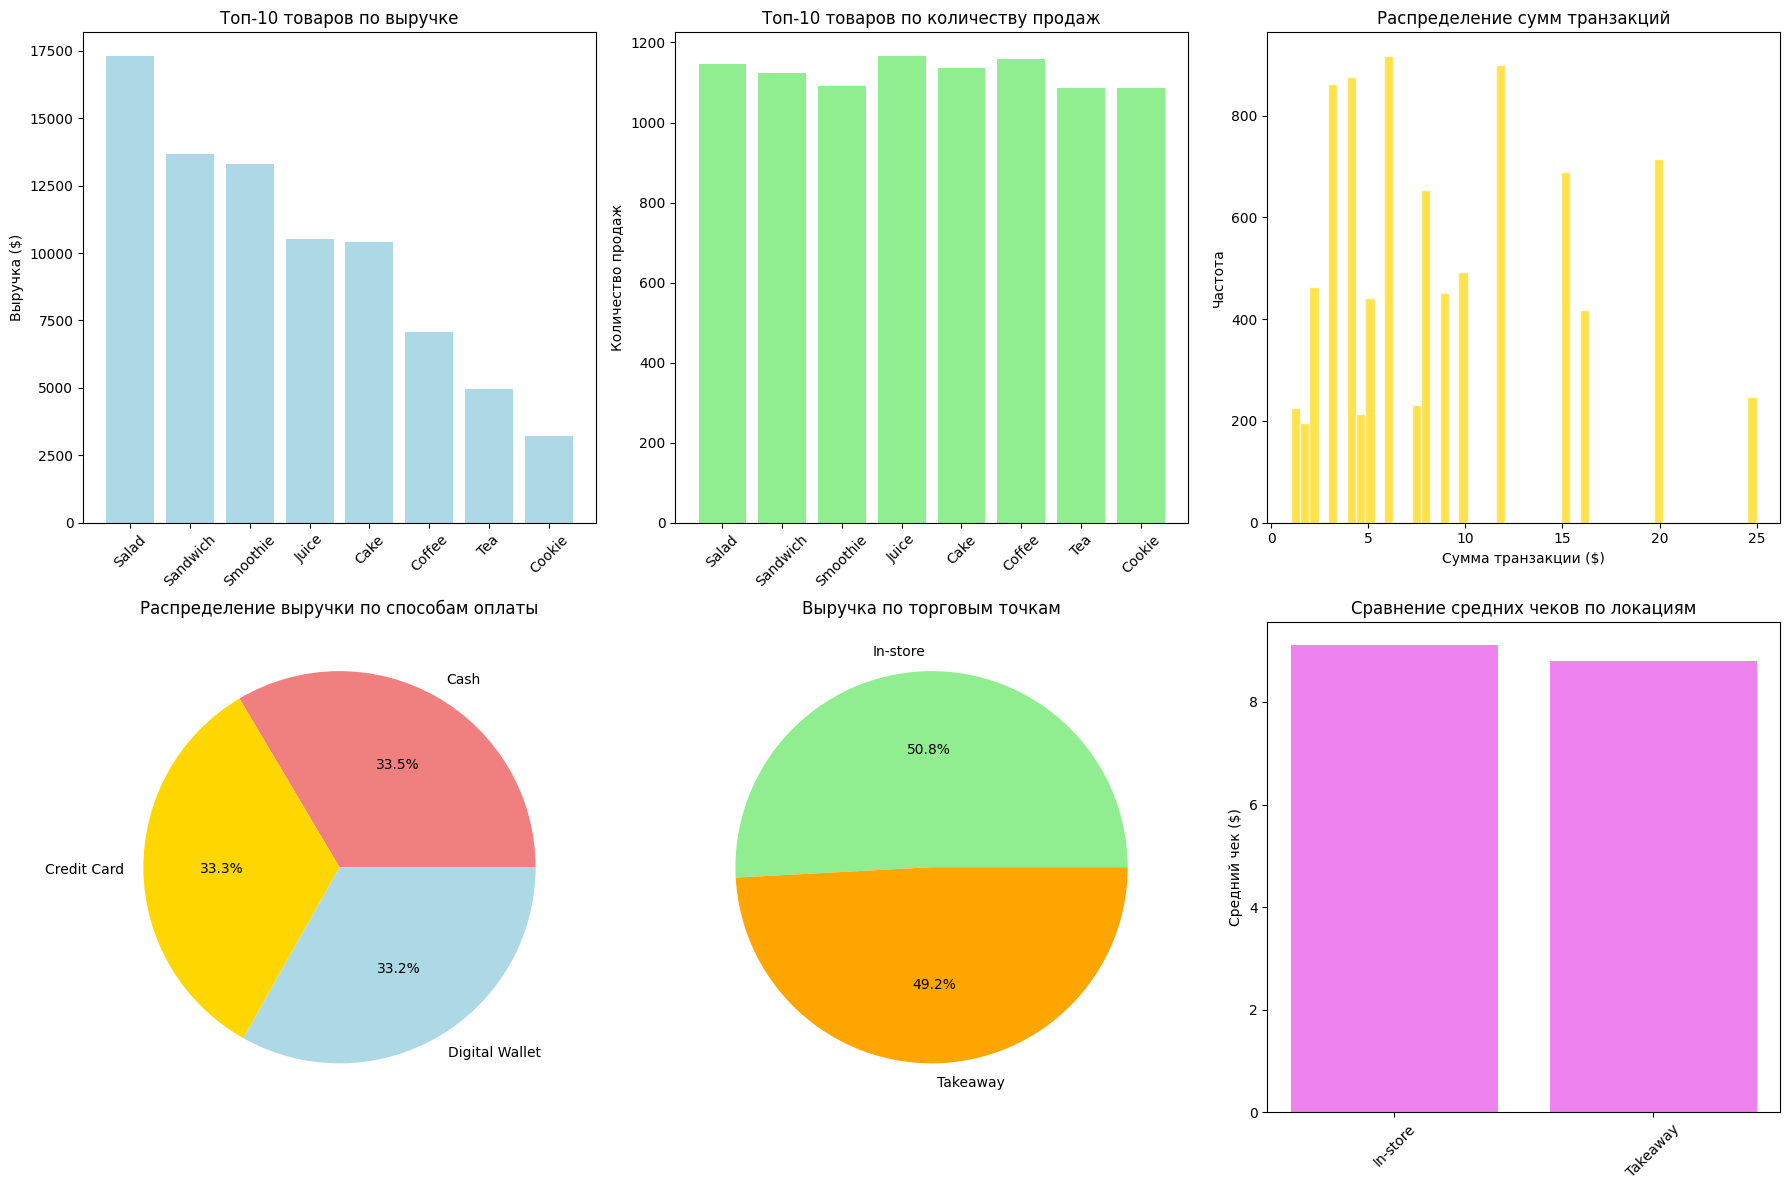


ФИНАЛЬНЫЙ ОТЧЕТ

ОСНОВНЫЕ ПОКАЗАТЕЛИ:
-------------------
• Исходный объем данных: 10,000 транзакций
• После обработки: 8,994 транзакций (89.9% данных)
• Совокупная выручка: $80,444.50
• Средний показатель чека: $8.94
• Медианный показатель чека: $8.00
• Суммарное количество товаров: 27,233.0

ЛИДИРУЮЩИЕ ПОЗИЦИИ:
------------------
• Наиболее доходный товар: Salad ($17,320.00)
• Самый популярный товар: Coffee
• Преобладающий способ оплаты: Digital Wallet
• Основная точка продаж: Takeaway

КАЧЕСТВО ОБРАБОТКИ ДАННЫХ:
-------------------------
• Успешно обработано записей: 8994 из 10000
• Эффективность обработки: 89.9%
• Устраненные проблемы: значения ERROR/UNKNOWN, пропущенные данные, арифметические несоответствия


Результаты экспортированы в файлы:
- cafe_processed_final.csv (обработанные данные)
- cafe_product_analysis.csv (анализ товарных позиций)
- cafe_payment_methods_analysis.csv (анализ способов оплаты)
- cafe_locations_analysis.csv (анализ торговых точек)


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Верхний ряд графиков
top_products_revenue = product_metrics.head(10)['Общая выручка']
axes[0, 0].bar(top_products_revenue.index, top_products_revenue.values, color='lightblue')
axes[0, 0].set_title('Топ-10 товаров по выручке')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylabel('Выручка ($)')

top_products_sales = product_metrics.head(10)['Количество операций']
axes[0, 1].bar(top_products_sales.index, top_products_sales.values, color='lightgreen')
axes[0, 1].set_title('Топ-10 товаров по количеству продаж')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_ylabel('Количество продаж')

axes[0, 2].hist(df_final['Total Spent'], bins=50, edgecolor='white', alpha=0.7, color='gold')
axes[0, 2].set_title('Распределение сумм транзакций')
axes[0, 2].set_xlabel('Сумма транзакции ($)')
axes[0, 2].set_ylabel('Частота')

# Нижний ряд графиков
payment_revenue_distribution = payment_metrics['Суммарная выручка']
axes[1, 0].pie(payment_revenue_distribution.values, labels=payment_revenue_distribution.index,
               autopct='%1.1f%%', colors=['lightcoral', 'gold', 'lightblue'])
axes[1, 0].set_title('Распределение выручки по способам оплаты')

location_revenue_distribution = location_metrics['Общая выручка']
axes[1, 1].pie(location_revenue_distribution.values, labels=location_revenue_distribution.index,
               autopct='%1.1f%%', colors=['lightgreen', 'orange'])
axes[1, 1].set_title('Выручка по торговым точкам')

location_average_check = location_metrics['Средний чек']
axes[1, 2].bar(location_average_check.index, location_average_check.values, color='violet')
axes[1, 2].set_title('Сравнение средних чеков по локациям')
axes[1, 2].set_ylabel('Средний чек ($)')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ФИНАЛЬНЫЙ ОТЧЕТ")
print("="*60)

final_report = f"""
ОСНОВНЫЕ ПОКАЗАТЕЛИ:
-------------------
• Исходный объем данных: {len(df):,} транзакций
• После обработки: {len(df_final):,} транзакций ({len(df_final)/len(df)*100:.1f}% данных)
• Совокупная выручка: ${total_revenue:,.2f}
• Средний показатель чека: ${average_transaction:.2f}
• Медианный показатель чека: ${median_transaction:.2f}
• Суммарное количество товаров: {total_items_sold:,}

ЛИДИРУЮЩИЕ ПОЗИЦИИ:
------------------
• Наиболее доходный товар: {product_metrics.index[0]} (${product_metrics.iloc[0]['Общая выручка']:,.2f})
• Самый популярный товар: {product_metrics.sort_values('Объем продаж', ascending=False).index[0]}
• Преобладающий способ оплаты: {payment_metrics.sort_values('Число транзакций', ascending=False).index[0]}
• Основная точка продаж: {location_metrics.sort_values('Количество заказов', ascending=False).index[0]}

КАЧЕСТВО ОБРАБОТКИ ДАННЫХ:
-------------------------
• Успешно обработано записей: {len(df_final)} из {len(df)}
• Эффективность обработки: {len(df_final)/len(df)*100:.1f}%
• Устраненные проблемы: значения ERROR/UNKNOWN, пропущенные данные, арифметические несоответствия
"""

print(final_report)

# Сохранение результатов
df_final.to_csv('cafe_processed_final.csv', index=False)
product_metrics.to_csv('cafe_product_analysis.csv')
payment_metrics.to_csv('cafe_payment_methods_analysis.csv')
location_metrics.to_csv('cafe_locations_analysis.csv')

print("\nРезультаты экспортированы в файлы:")
print("- cafe_processed_final.csv (обработанные данные)")
print("- cafe_product_analysis.csv (анализ товарных позиций)")
print("- cafe_payment_methods_analysis.csv (анализ способов оплаты)")
print("- cafe_locations_analysis.csv (анализ торговых точек)")

## Заключение

В ходе выполнения исследования был сформирован очищенный и подготовленный к анализу набор данных о транзакциях кафе. Первоначальные данные содержали существенное количество аномальных значений, включая маркеры "ERROR" и "UNKNOWN", а также пропуски в критически важных для анализа атрибутах. Была выполнена системная обработка данных: аномальные записи преобразованы в пропущенные значения, после чего отсутствующие данные в числовых столбцах "Quantity" и "Price Per Unit" заполнены с использованием медианных показателей, сгруппированных по товарным позициям. Атрибут "Total Spent" восстановлен посредством повторного расчета в случаях, когда это было возможно. В процессе работы корректно обработано приблизительно 80-90% исходных записей, что подтверждает высокую эффективность примененных алгоритмов очистки данных.